# Module 1 — Why Python?
### *Excel to Python for Finance Professionals*

> ### ▶ Running this notebook in Google Colab (recommended)
> 1. Go to [colab.research.google.com](https://colab.research.google.com)
> 2. Click **File → Upload notebook**
> 3. Select this `.ipynb` file from your downloaded course ZIP
> 4. Click **Runtime → Run all**
>
> Alternatively: upload the whole ZIP to **Google Drive**, then double-click any notebook — it opens in Colab automatically.
>
> _No installation required. All you need is a free Google account._

> **Running this notebook:** We recommend [Google Colab](https://colab.research.google.com) — it runs entirely in your browser with no installation required. Just click the badge above. Alternatively, you can run locally using Anaconda + Jupyter Lab (see Section 1.3).

---

Welcome. If you've spent years building financial models in Excel, switching to Python can feel unnecessary — even risky. Excel works. You know it. Your colleagues know it.

This module makes the honest case for Python: not as a replacement for everything Excel does, but as a significantly better tool for the work that actually matters — complex modelling, large datasets, repeatable analysis, and professional reporting.

By the end of this notebook you will have:
- Understood exactly where Python beats Excel (and where it doesn't)
- Set up your Python environment
- Loaded a real Excel P&L file into Python and reproduced it in pandas

---

## 1.1 — The Honest Comparison

Excel is a genuinely great tool. It has an intuitive grid interface, it's universal, and for quick one-off calculations it's hard to beat. So let's be specific about where it falls short.

| Task | Excel | Python |
|---|---|---|
| Quick calculation | ✅ Excellent | ❌ Overkill |
| Sharing with non-technical stakeholders | ✅ Universal | ⚠️ Needs export step |
| Models with 100k+ rows | ❌ Slow, crashes | ✅ Handles millions |
| Reproducibility & auditability | ❌ Formula errors, hidden logic | ✅ Code is self-documenting |
| Version control | ❌ "model_FINAL_v3_REAL.xlsx" | ✅ Git tracks every change |
| Automation & scheduling | ❌ Manual every time | ✅ Run on a schedule |
| Scenario analysis at scale | ⚠️ Data tables are limited | ✅ Loop over thousands of scenarios |
| Connecting to live data | ❌ Painful | ✅ Native API/database support |
| Reusable model components | ❌ Copy-paste sheets | ✅ Import functions across projects |

**The core insight:** Excel is optimised for *human interaction*. Python is optimised for *repeatability and scale*. As a finance professional, you increasingly need both — and Python handles the hard parts better.

---

## 1.2 — The Hidden Cost of Excel Models

Think about the last complex model you built or inherited. How many of these applied?

- Hard-coded numbers buried inside formulas
- Assumptions scattered across multiple tabs with no clear index
- A formula that references a cell three sheets away — and nobody knows why
- A colleague who slightly modified it, and now the totals don't match
- A monthly report that takes two hours to update manually

These aren't Excel user errors. They're structural limitations of spreadsheet-based modelling. Python eliminates most of them by design:

- Assumptions live in one place (a dictionary or config file)
- Logic is explicit, readable code — not hidden formula chains
- Updating a model means re-running a script, not hunting through cells
- Version control means you can always see who changed what and when

---

## 1.3 — Setting Up Your Environment

There are two ways to run this course. Choose whichever suits you.

---

### ✅ Option A: Google Colab (recommended — no installation needed)

1. Click the **Open in Colab** badge at the top of this notebook
2. Sign in with a Google account
3. Click **Runtime → Run all** to execute every cell

Colab comes with pandas, numpy, and matplotlib pre-installed. We just need to install `openpyxl`:
```
!pip install openpyxl --quiet
```
This is already handled in the setup cell below — you don't need to do anything manually.

> **Note on file uploads in Colab:** Colab runs in the cloud, so it can't directly access files on your computer. In Section 1.5, we generate the sample Excel file programmatically so the exercise is fully self-contained. In later modules, when you want to load *your own* Excel files, use this snippet:
> ```python
> from google.colab import files
> uploaded = files.upload()  # Opens a file picker
> import io
> df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))
> ```

---

### Option B: Local install (Anaconda + Jupyter Lab)

Prefer to work offline or want a permanent local setup?

1. Download Anaconda: https://www.anaconda.com/download
2. Launch Jupyter Lab from your terminal: `jupyter lab`
3. Install extra libraries once: `pip install openpyxl plotly`

---

Run the cell below to confirm your environment is ready (works in both Colab and local):

In [10]:
# Auto-install openpyxl if running in Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'openpyxl', '--quiet'])
    print("📦 Colab detected — openpyxl installed.")
else:
    print("💻 Local environment detected.")

# Confirm your environment is set up correctly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

print(f"pandas:    {pd.__version__}")
print(f"numpy:     {np.__version__}")
print(f"openpyxl:  {openpyxl.__version__}")
print("\n✅ Environment ready.")

💻 Local environment detected.
pandas:    1.0.1
numpy:     1.18.1
openpyxl:  3.0.3

✅ Environment ready.


---

## 1.4 — Core Concepts: Thinking in pandas

The mental shift from Excel to Python is simpler than it looks. Here's the mapping:

| Excel concept | Python / pandas equivalent |
|---|---|
| Workbook (.xlsx) | Script or notebook (.py / .ipynb) |
| Sheet | DataFrame |
| Row | Row (index) |
| Column | Series |
| Cell formula | Python expression or function |
| Named range | Variable |
| Pivot table | `df.groupby().agg()` |
| VLOOKUP | `df.merge()` |

A **DataFrame** is the core object in pandas. Think of it as a spreadsheet tab that lives in memory — it has rows, columns, and you can apply operations across the whole thing at once (no dragging formulas down).

Let's build a simple one from scratch:

In [11]:
import pandas as pd

# Think of this as typing values into a spreadsheet
data = {
    'Month':   ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Revenue': [120000, 135000, 128000, 142000, 155000, 161000],
    'COGS':    [ 48000,  52000,  51000,  56000,  60000,  63000],
}

df = pd.DataFrame(data)

# This is your spreadsheet
df

,Month,Revenue,COGS
0,Jan,120000,48000
1,Feb,135000,52000
2,Mar,128000,51000
3,Apr,142000,56000
4,May,155000,60000
5,Jun,161000,63000


In [12]:
# Adding a calculated column — like writing a formula in Excel
# No dragging down required. It applies to every row instantly.
df['Gross Profit'] = df['Revenue'] - df['COGS']
df['Gross Margin %'] = (df['Gross Profit'] / df['Revenue'] * 100).round(1)

df

,Month,Revenue,COGS,Gross Profit,Gross Margin %
0,Jan,120000,48000,72000,60.0
1,Feb,135000,52000,83000,61.5
2,Mar,128000,51000,77000,60.2
3,Apr,142000,56000,86000,60.6
4,May,155000,60000,95000,61.3
5,Jun,161000,63000,98000,60.9


Notice how clean this is. `df['Gross Profit'] = df['Revenue'] - df['COGS']` is more readable than `=B2-C2` copied down 50 rows — and it's impossible to accidentally leave one row with the wrong formula.

---

## 1.5 — Notebook Exercise: Load a Real Excel P&L into Python

Now let's do something practical. We'll create a sample P&L Excel file (simulating one you'd receive from a colleague), load it into Python, and reproduce the key metrics.

### Step 1: Create a sample Excel P&L file

In real life you'd already have this file. We'll generate it here so the exercise is self-contained:

In [13]:
import openpyxl
from openpyxl import Workbook

# Create a sample P&L Excel file — as if a colleague sent it to you
wb = Workbook()
ws = wb.active
ws.title = "P&L"

# Headers
headers = ['Month', 'Revenue', 'COGS', 'Gross Profit', 
           'OpEx', 'EBITDA', 'D&A', 'EBIT']
ws.append(headers)

# Monthly data (£000s)
rows = [
    ['Jan', 120, 48, 72, 30, 42, 5, 37],
    ['Feb', 135, 52, 83, 33, 50, 5, 45],
    ['Mar', 128, 51, 77, 31, 46, 5, 41],
    ['Apr', 142, 56, 86, 34, 52, 5, 47],
    ['May', 155, 60, 95, 37, 58, 5, 53],
    ['Jun', 161, 63, 98, 38, 60, 5, 55],
    ['Jul', 158, 62, 96, 37, 59, 5, 54],
    ['Aug', 149, 59, 90, 36, 54, 5, 49],
    ['Sep', 163, 64, 99, 39, 60, 5, 55],
    ['Oct', 171, 67, 104, 41, 63, 5, 58],
    ['Nov', 182, 71, 111, 43, 68, 5, 63],
    ['Dec', 195, 76, 119, 46, 73, 5, 68],
]

for row in rows:
    ws.append(row)

wb.save('sample_pl.xlsx')
print("✅ sample_pl.xlsx created successfully.")

✅ sample_pl.xlsx created successfully.


### Step 2: Load the Excel file into pandas

In [15]:
# This single line replaces opening Excel, finding the sheet, selecting the data
pl = pd.read_excel('sample_pl.xlsx', sheet_name='P&L')

print(f"Loaded {len(pl)} rows and {len(pl.columns)} columns")
print(f"Columns: {list(pl.columns)}")
print()
pl

Loaded 12 rows and 8 columns
Columns: ['Month', 'Revenue', 'COGS', 'Gross Profit', 'OpEx', 'EBITDA', 'D&A', 'EBIT']



,Month,Revenue,COGS,Gross Profit,OpEx,EBITDA,D&A,EBIT
0,Jan,120,48,72,30,42,5,37
1,Feb,135,52,83,33,50,5,45
2,Mar,128,51,77,31,46,5,41
3,Apr,142,56,86,34,52,5,47
4,May,155,60,95,37,58,5,53
5,Jun,161,63,98,38,60,5,55
6,Jul,158,62,96,37,59,5,54
7,Aug,149,59,90,36,54,5,49
8,Sep,163,64,99,39,60,5,55
9,Oct,171,67,104,41,63,5,58


### Step 3: Reproduce key P&L metrics in Python

In [16]:
# Margin analysis — the kind of thing you'd build formula columns for in Excel
pl['Gross Margin %'] = (pl['Gross Profit'] / pl['Revenue'] * 100).round(1)
pl['EBITDA Margin %'] = (pl['EBITDA']       / pl['Revenue'] * 100).round(1)
pl['EBIT Margin %']   = (pl['EBIT']         / pl['Revenue'] * 100).round(1)

# Select just the margin view
margins = pl[['Month', 'Revenue', 'Gross Margin %', 'EBITDA Margin %', 'EBIT Margin %']]
margins

,Month,Revenue,Gross Margin %,EBITDA Margin %,EBIT Margin %
0,Jan,120,60.0,35.0,30.8
1,Feb,135,61.5,37.0,33.3
2,Mar,128,60.2,35.9,32.0
3,Apr,142,60.6,36.6,33.1
4,May,155,61.3,37.4,34.2
5,Jun,161,60.9,37.3,34.2
6,Jul,158,60.8,37.3,34.2
7,Aug,149,60.4,36.2,32.9
8,Sep,163,60.7,36.8,33.7
9,Oct,171,60.8,36.8,33.9


In [17]:
# Full-year summary — like an Excel totals row, but automatic
summary = pd.DataFrame({
    'Metric': ['Revenue', 'Gross Profit', 'EBITDA', 'EBIT'],
    'FY Total (£000s)': [
        pl['Revenue'].sum(),
        pl['Gross Profit'].sum(),
        pl['EBITDA'].sum(),
        pl['EBIT'].sum()
    ]
})

# Add margin column
summary['FY Margin %'] = (
    summary['FY Total (£000s)'] / pl['Revenue'].sum() * 100
).round(1)

print("Full Year P&L Summary")
print("=" * 45)
summary

Full Year P&L Summary


,Metric,FY Total (£000s),FY Margin %
0,Revenue,1859,100.0
1,Gross Profit,1130,60.8
2,EBITDA,685,36.8
3,EBIT,625,33.6


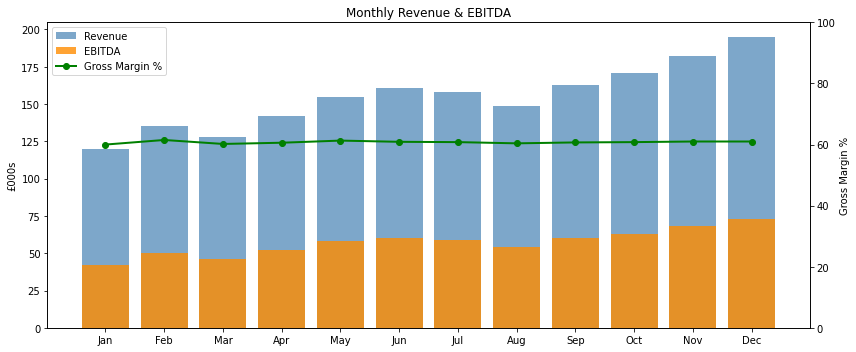

In [18]:
# Quick revenue trend chart — better than an Excel chart because it's reproducible
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

# Revenue bars
ax1.bar(pl['Month'], pl['Revenue'], color='steelblue', alpha=0.7, label='Revenue')
ax1.bar(pl['Month'], pl['EBITDA'], color='darkorange', alpha=0.8, label='EBITDA')
ax1.set_ylabel('£000s')
ax1.set_title('Monthly Revenue & EBITDA')

# Gross margin % line on secondary axis
ax2 = ax1.twinx()
ax2.plot(pl['Month'], pl['Gross Margin %'], 
         color='green', marker='o', linewidth=2, label='Gross Margin %')
ax2.set_ylabel('Gross Margin %')
ax2.set_ylim(0, 100)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

---

## 1.6 — What Just Happened (and Why It Matters)

Let's take stock of what we built in about 20 lines of code:

1. **Loaded** an Excel file without opening Excel
2. **Calculated** gross margin, EBITDA margin, and EBIT margin across 12 months — with zero risk of a formula error in one row
3. **Summarised** the full year P&L automatically
4. **Charted** revenue, EBITDA, and gross margin on a dual-axis chart

Now consider: if you received an updated Excel file next month, how long would the update take?

```python
pl = pd.read_excel('sample_pl_updated.xlsx', sheet_name='P&L')
```

One line. Every calculation, every chart, every summary updates automatically. **That** is the core value proposition of Python for finance.

---

## 1.7 — Key Takeaways

- Python doesn't replace Excel for everything — it replaces Excel for the *hard* parts: large data, complex models, automation, and reproducibility
- A pandas DataFrame is just a spreadsheet in memory — the concepts map directly
- `pd.read_excel()` is your gateway from the Excel world to Python
- Column-level operations replace formula-dragging, and they can never have a row-level error
- The payoff is compounding: every model you build in Python is reusable, auditable, and automatable

---

## Up Next: Module 2 — Python for Finance Fundamentals

We'll go deeper on the Excel-to-Python translation: VLOOKUP → merge, SUMIF → groupby, pivot tables, and date handling for time series data.